In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("muted")
pd.set_option('display.max_columns', None)

In [19]:
file_path = '../data/raw/German Credit Dataset/german_credit.csv' 

try:
    df = pd.read_csv(file_path, sep=',') 
    print(f"Dimension: {df.shape}")
    display(df.head())
except Exception as e:
    print(f"Error: {e}")

Dimension: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [20]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   checking_status         1000 non-null   str  
 1   duration                1000 non-null   int64
 2   credit_history          1000 non-null   str  
 3   purpose                 1000 non-null   str  
 4   credit_amount           1000 non-null   int64
 5   savings_status          1000 non-null   str  
 6   employment              1000 non-null   str  
 7   installment_commitment  1000 non-null   int64
 8   personal_status         1000 non-null   str  
 9   other_parties           1000 non-null   str  
 10  residence_since         1000 non-null   int64
 11  property_magnitude      1000 non-null   str  
 12  age                     1000 non-null   int64
 13  other_payment_plans     1000 non-null   str  
 14  housing                 1000 non-null   str  
 15  existing_credits        1000 non-

None

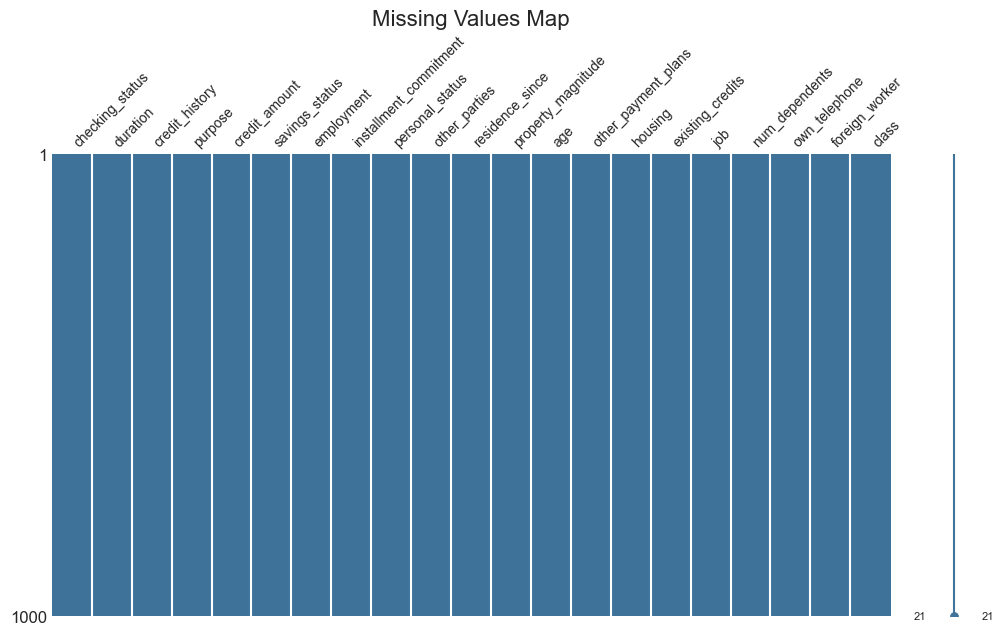

In [21]:
msno.matrix(df, figsize=(12, 6), fontsize=10, color=(0.25, 0.45, 0.6))
plt.title('Missing Values Map', fontsize=16)
plt.show()

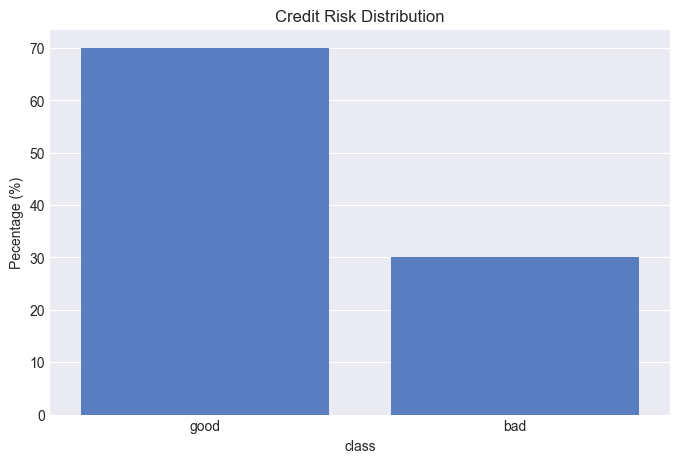

class
good    70.0
bad     30.0
Name: proportion, dtype: float64

In [22]:
target_col = df.columns[-1]

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x=target_col, ax=ax, stat='percent')
plt.title('Credit Risk Distribution')
plt.ylabel('Pecentage (%)')
plt.show()

display(df[target_col].value_counts(normalize=True) * 100)

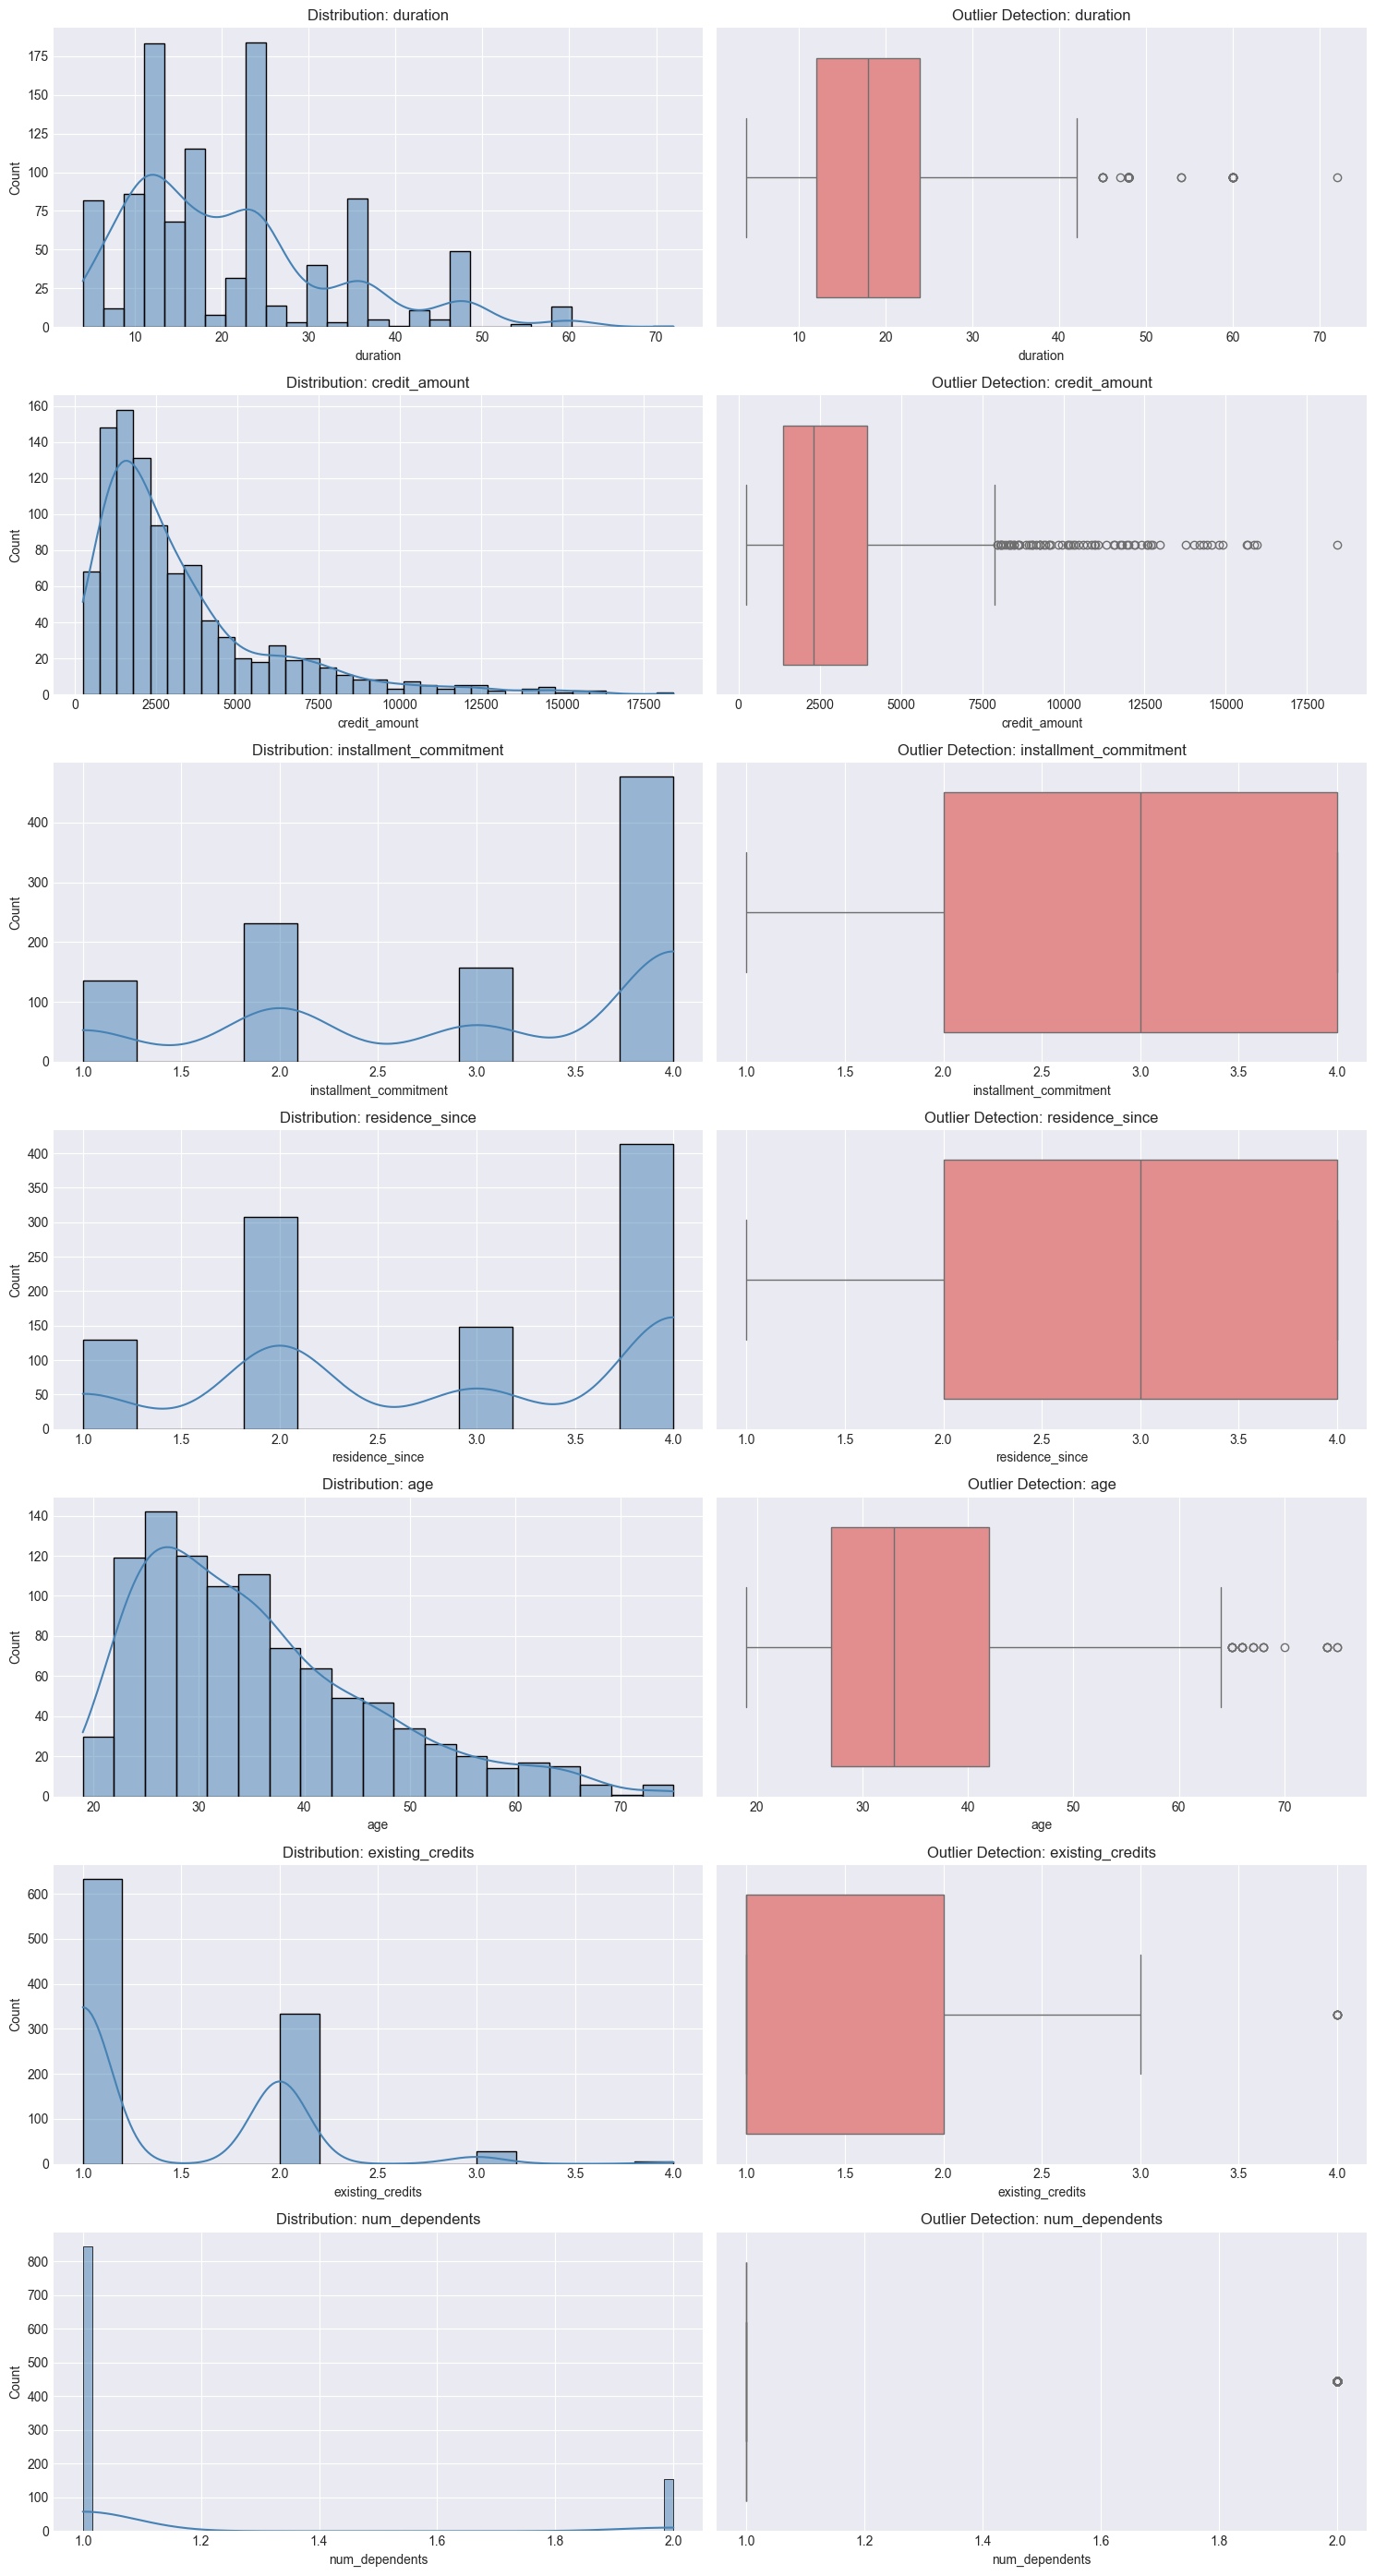

In [28]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)

fig, axes = plt.subplots(len(num_cols), 2, figsize=(15, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Distribution: {col}')
    
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Outlier Detection: {col}')

plt.tight_layout()
plt.savefig("outlier", dpi=300, bbox_inches="tight")
plt.show()

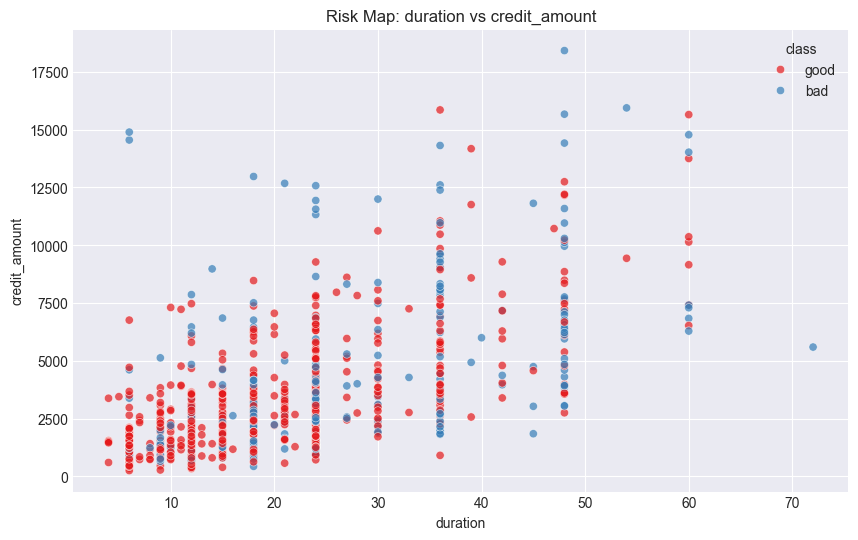

In [27]:
if len(num_cols) >= 2:
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df, 
        x=num_cols[0], 
        y=num_cols[1], 
        hue=target_col, 
        alpha=0.7, 
        palette='Set1'
    )
    
    plt.title(f'Risk Map: {num_cols[0]} vs {num_cols[1]}')
    plt.savefig("risk_map", dpi=300, bbox_inches="tight")
    plt.show()

In [37]:
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
ordinal_cols = ['installment_commitment', 'residence_since', 'existing_credits', 'num_dependents']
cat_cols = list(set(cat_cols + ordinal_cols))

if target_col in cat_cols:
    cat_cols.remove(target_col)

df_temp = df.copy()
df_temp['target_num'] = df_temp[target_col].map({'bad': 1, 'good': 0})

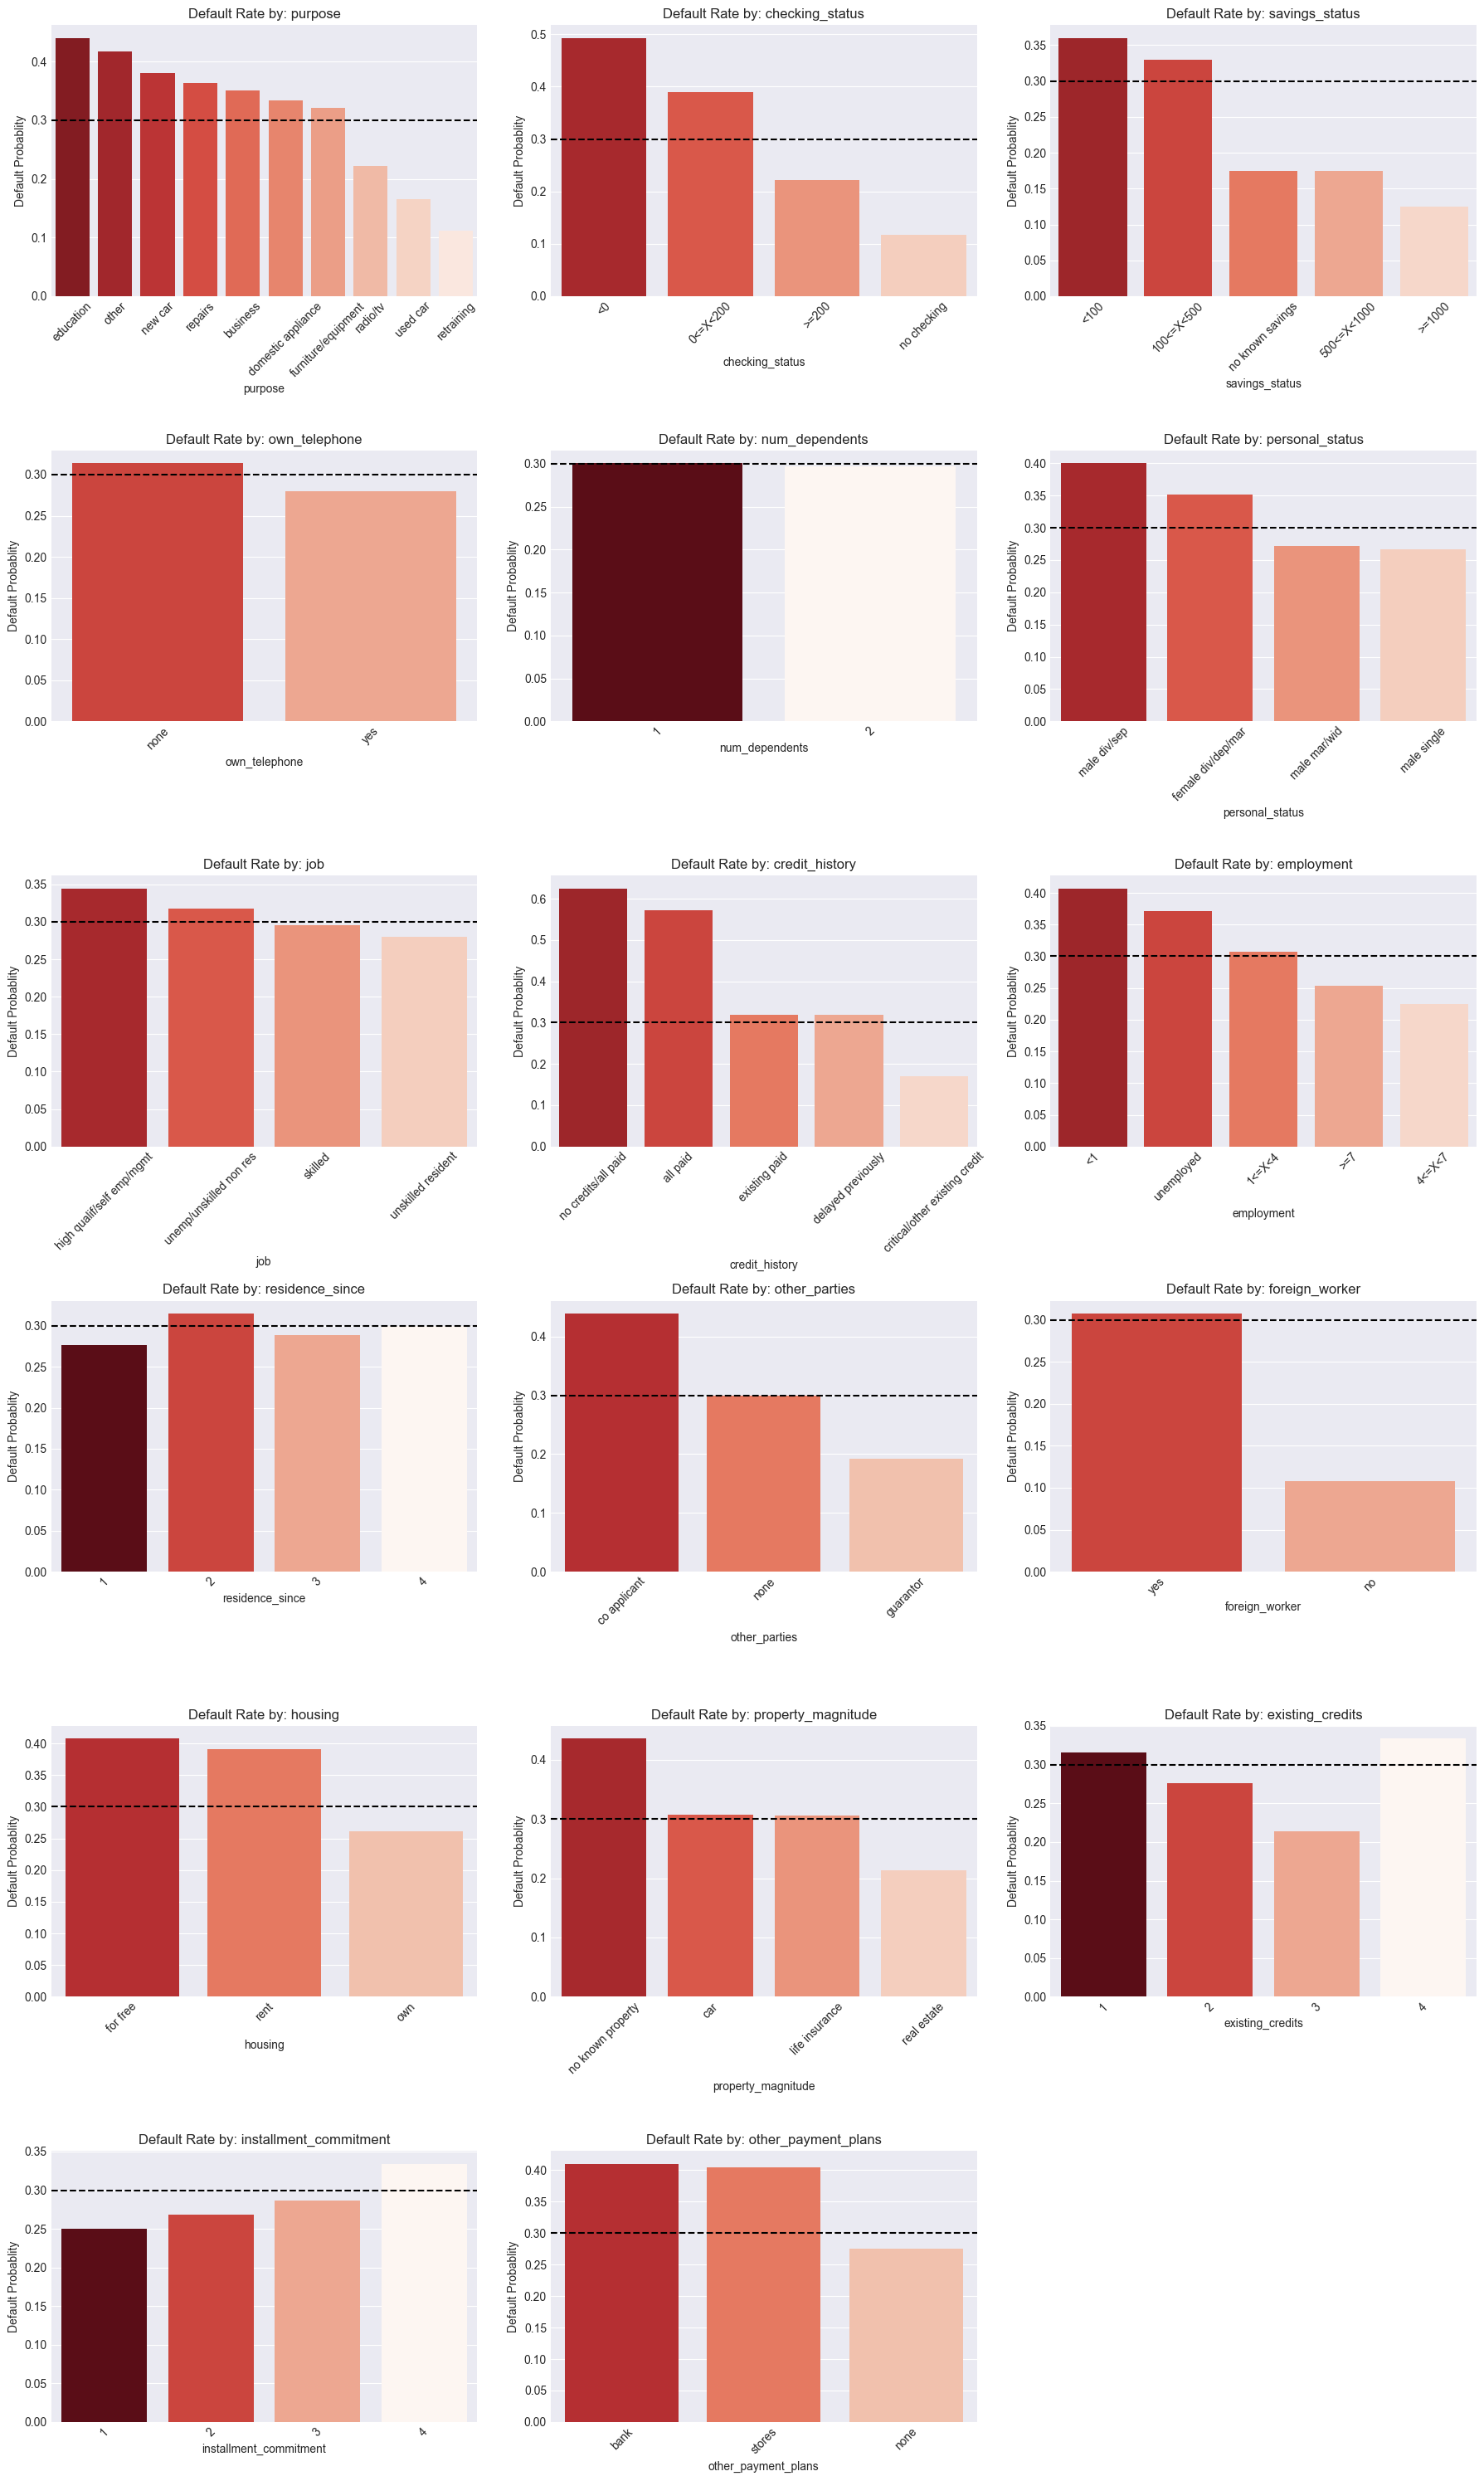

In [40]:
num_plots = len(cat_cols)
cols_per_row = 3
rows = int(np.ceil(num_plots / cols_per_row))

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    risk_table = df_temp.groupby(col)['target_num'].mean().sort_values(ascending=False)
    
    sns.barplot(x=risk_table.index, y=risk_table.values, ax=axes[i], hue=risk_table.index, palette='Reds_r', legend=False)
    axes[i].set_title(f'Default Rate by: {col}', fontsize=12)
    axes[i].set_ylabel('Default Probablity')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(df_temp['target_num'].mean(), color='black', linestyle='--', label='Global Average')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("def_rate_by", dpi=300, bbox_inches="tight")
plt.show()

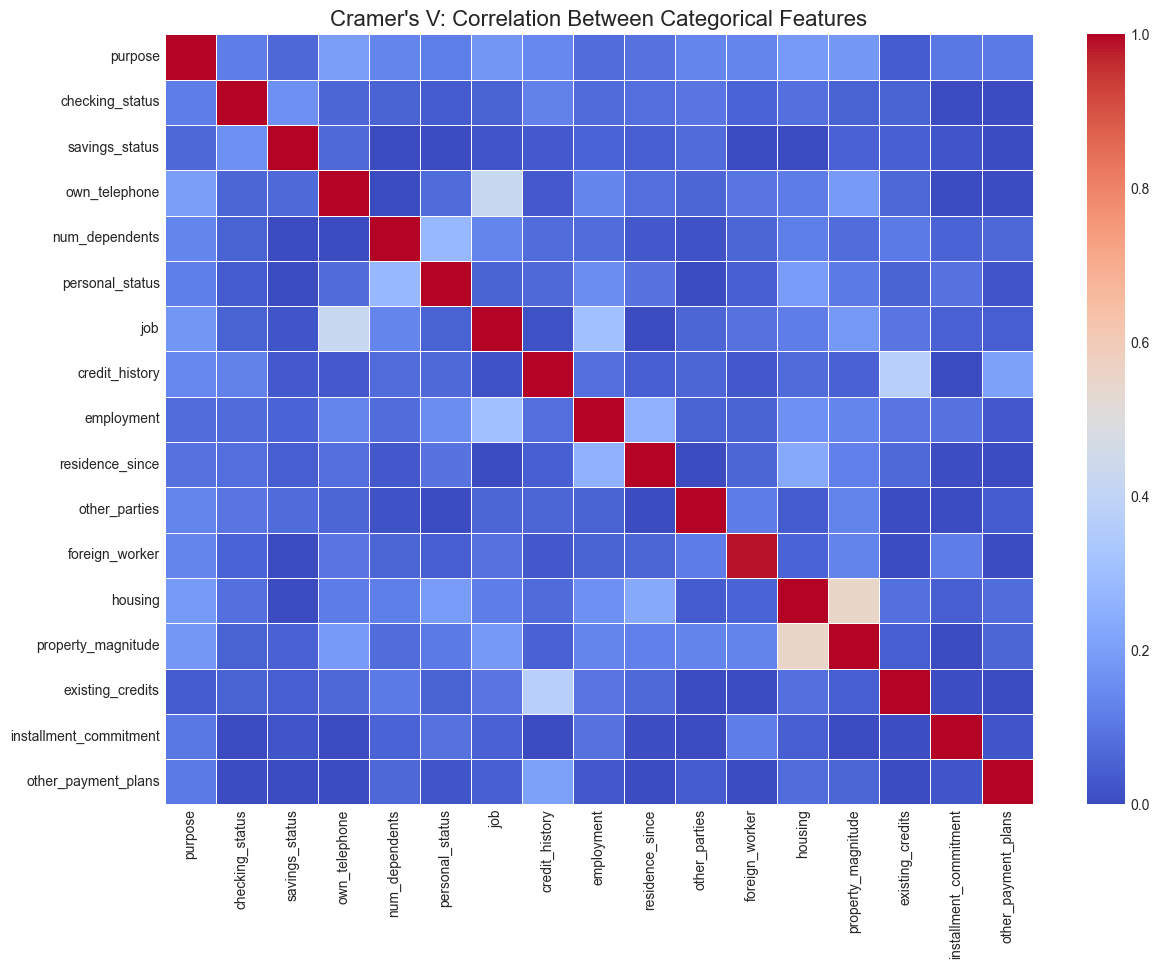

,level_0,level_1,0
0,purpose,purpose,1.000000
18,checking_status,checking_status,1.000000
36,savings_status,savings_status,1.000000
54,own_telephone,own_telephone,0.997921
72,num_dependents,num_dependents,0.996179
90,personal_status,personal_status,1.000000
108,job,job,1.000000
126,credit_history,credit_history,1.000000
144,employment,employment,1.000000
162,residence_since,residence_since,1.000000


In [39]:
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramer_matrix = cramer_matrix.astype(float)

plt.figure(figsize=(14, 10))
sns.heatmap(cramer_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1, linewidths=0.5)
plt.title("Cramer's V: Correlation Between Categorical Features", fontsize=16)
plt.savefig("cat_feat_corr", dpi=300, bbox_inches="tight")
plt.show()

display(cramer_matrix[cramer_matrix > 0.6].stack().reset_index().drop_duplicates().dropna())